# Customer Segmentation

Segment customers by **behavior** (RFM: recency, frequency, monetary) and
**demographics** (age, income, region, tenure, channel preference) using
K-Means clustering.

**Workflow:** load & clean → engineer/scale features → pick `k` (elbow +
silhouette) → cluster → profile & name segments → translate into action.

> Run `python generate_data.py` once first to create `data/customers.csv`.


In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
sns.set_theme(style="whitegrid")

df = pd.read_csv("data/customers.csv")
print(df.shape)
df.head()

(2000, 12)


,customer_id,age,gender,region,annual_income_k,tenure_months,recency_days,frequency_yr,avg_order_value,monetary_total,online_ratio,_true_persona
0,100000,60,Female,East,85.5,33,240,3,26.05,78.16,0.431,Lapsed Customer
1,100001,38,Male,South,56.5,36,31,7,57.30,401.11,0.540,Mid-Market Regular
2,100002,48,Male,South,56.3,43,332,5,35.88,179.38,0.725,Lapsed Customer
3,100003,53,Female,West,103.7,78,49,4,275.01,1100.06,0.284,Occasional Big Spender
4,100004,19,Male,West,28.6,49,32,7,22.07,154.47,0.874,Young Budget Shopper


## 1. Clean & explore

In [2]:
# Median-impute missing income; drop dup IDs.
df["annual_income_k"] = df["annual_income_k"].fillna(df["annual_income_k"].median())
df = df.drop_duplicates(subset="customer_id")
df.describe().round(1)

,customer_id,age,annual_income_k,tenure_months,recency_days,frequency_yr,avg_order_value,monetary_total,online_ratio
count,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0
mean,100999.5,41.4,71.2,36.6,92.3,9.0,106.0,1101.2,0.6
std,577.5,14.8,37.8,22.3,128.4,6.5,101.1,1777.5,0.2
min,100000.0,18.0,12.0,1.0,1.0,1.0,5.0,17.1,0.0
25%,100499.8,29.0,42.8,19.8,20.0,4.0,39.2,220.8,0.4
50%,100999.5,41.0,63.2,36.0,39.0,8.0,60.5,422.4,0.6
75%,101499.2,50.0,89.5,52.0,84.0,11.0,149.5,827.3,0.7
max,101999.0,82.0,188.4,103.0,551.0,32.0,416.7,10392.4,1.0


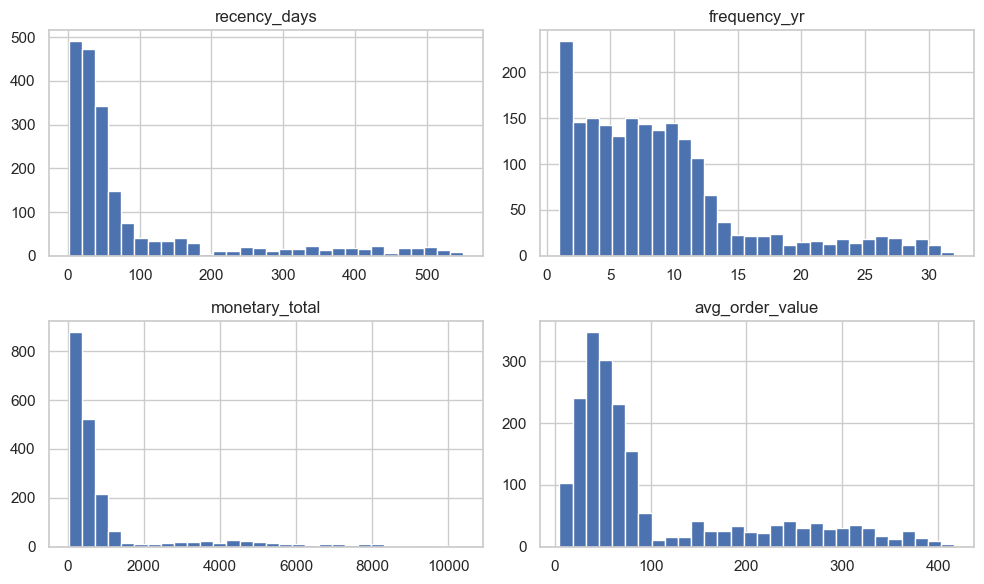

In [3]:
# Distributions of the behavioral features.
behav = ["recency_days", "frequency_yr", "monetary_total", "avg_order_value"]
df[behav].hist(bins=30, figsize=(10, 6)); plt.tight_layout(); plt.show()

## 2. Feature scaling
K-Means uses Euclidean distance, so features must be on a comparable scale.

In [4]:
FEATURES = ["age", "annual_income_k", "tenure_months", "recency_days",
            "frequency_yr", "avg_order_value", "monetary_total", "online_ratio"]
X = StandardScaler().fit_transform(df[FEATURES])
X.shape

(2000, 8)

## 3. Choose k — elbow + silhouette

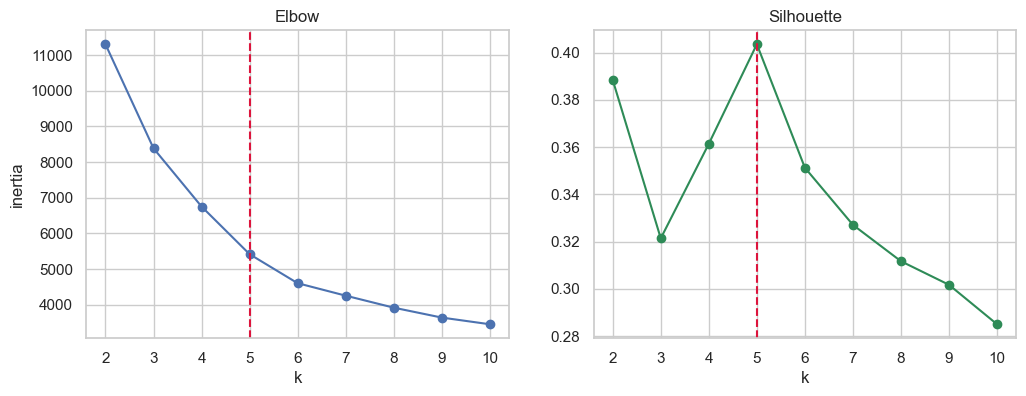

Selected k = 5


In [5]:
rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    lab = km.fit_predict(X)
    rows.append({"k": k, "inertia": km.inertia_, "silhouette": silhouette_score(X, lab)})
scores = pd.DataFrame(rows)
best_k = int(scores.loc[scores.silhouette.idxmax(), "k"])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(scores.k, scores.inertia, "o-"); ax[0].set(title="Elbow", xlabel="k", ylabel="inertia")
ax[1].plot(scores.k, scores.silhouette, "o-", color="seagreen"); ax[1].set(title="Silhouette", xlabel="k")
for a in ax: a.axvline(best_k, color="crimson", ls="--")
plt.show()
print("Selected k =", best_k)

## 4. Fit K-Means

In [6]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=42)
df["cluster"] = km.fit_predict(X)
df["cluster"].value_counts().sort_index()

cluster
0    293
1    929
2    291
3    221
4    266
Name: count, dtype: int64

## 5. Visualize segments (PCA to 2D)

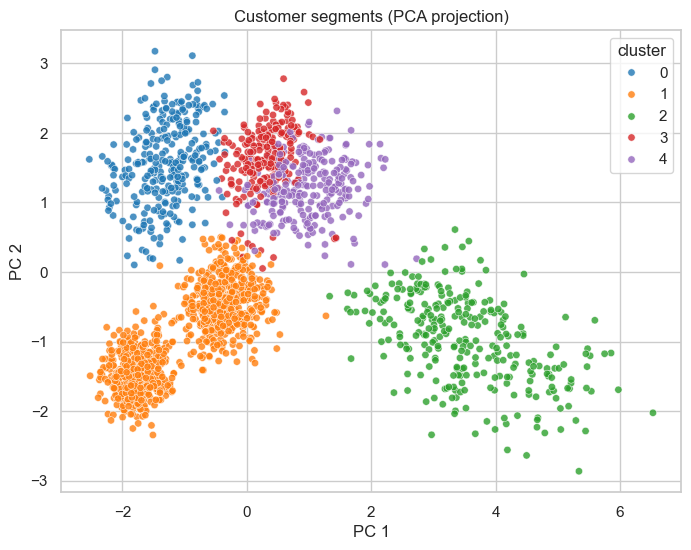

In [7]:
coords = PCA(n_components=2, random_state=42).fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df["cluster"],
                palette="tab10", s=28, alpha=0.8)
plt.title("Customer segments (PCA projection)"); plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.legend(title="cluster"); plt.show()

## 6. Profile & name the segments

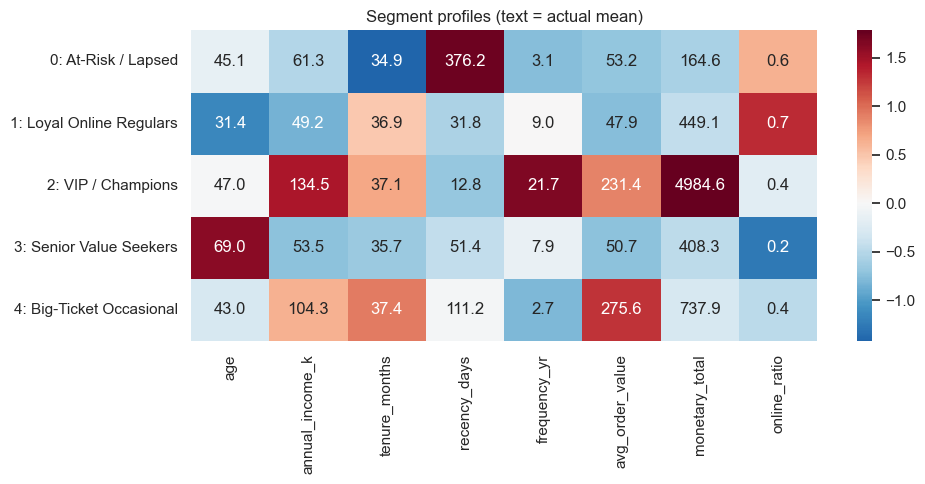

In [8]:
profile = df.groupby("cluster")[FEATURES].mean()

def label(row):
    spend_hi, rec_hi = profile.monetary_total.quantile(.66), profile.recency_days.quantile(.66)
    freq_hi, aov_hi = profile.frequency_yr.median(), profile.avg_order_value.quantile(.66)
    age_hi, on_hi = profile.age.quantile(.75), profile.online_ratio.median()
    if row.monetary_total >= spend_hi and row.frequency_yr >= freq_hi: return "VIP / Champions"
    if row.avg_order_value >= aov_hi and row.frequency_yr <= freq_hi:   return "Big-Ticket Occasional"
    if row.recency_days >= rec_hi and row.frequency_yr <= freq_hi:      return "At-Risk / Lapsed"
    if row.age >= age_hi and row.online_ratio < on_hi:                  return "Senior Value Seekers"
    if row.frequency_yr >= freq_hi and row.online_ratio >= on_hi:       return "Loyal Online Regulars"
    return "Mid-Market Regulars"

names = {seg: f"{seg}: {label(r)}" for seg, r in profile.iterrows()}
df["segment"] = df["cluster"].map(names)

z = (profile - profile.mean()) / profile.std()
z.index = [names[i] for i in z.index]
plt.figure(figsize=(10, 5))
sns.heatmap(z, annot=profile.round(1).set_axis([names[i] for i in profile.index]),
            fmt=".1f", cmap="RdBu_r", center=0)
plt.title("Segment profiles (text = actual mean)"); plt.tight_layout(); plt.show()

In [9]:
summary = (df.groupby("segment")
    .agg(customers=("customer_id", "size"),
         pct=("customer_id", lambda s: round(100*len(s)/len(df), 1)),
         avg_age=("age", "mean"), avg_income_k=("annual_income_k", "mean"),
         avg_recency=("recency_days", "mean"), avg_freq=("frequency_yr", "mean"),
         avg_spend=("monetary_total", "mean"), online_ratio=("online_ratio", "mean"))
    .round(1).sort_values("avg_spend", ascending=False))
summary

,customers,pct,avg_age,avg_income_k,avg_recency,avg_freq,avg_spend,online_ratio
segment,,,,,,,,
2: VIP / Champions,291,14.6,47.0,134.5,12.8,21.7,4984.6,0.4
4: Big-Ticket Occasional,266,13.3,43.0,104.3,111.2,2.7,737.9,0.4
1: Loyal Online Regulars,929,46.5,31.4,49.2,31.8,9.0,449.1,0.7
3: Senior Value Seekers,221,11.1,69.0,53.5,51.4,7.9,408.3,0.2
0: At-Risk / Lapsed,293,14.7,45.1,61.3,376.2,3.1,164.6,0.6


## 7. From segments to action

| Segment | Who they are | Recommended play |
|---|---|---|
| **VIP / Champions** | High spend, frequent, high income | VIP perks, early access, referral asks |
| **Big-Ticket Occasional** | Large but rare orders | Targeted high-value launches, financing offers |
| **Loyal Online Regulars** | Frequent mid-value, online-first | Subscriptions, app engagement, cross-sell |
| **Senior Value Seekers** | Older, offline, value-driven | Loyalty discounts, in-store / mail outreach |
| **At-Risk / Lapsed** | Haven't bought in a long time | Win-back campaign, reactivation discount |

**Validation:** because the synthetic data was built from hidden personas, we can
check the clustering against ground truth:

In [10]:
if "_true_persona" in df.columns:
    display(pd.crosstab(df["segment"], df["_true_persona"]))

_true_persona,Affluent Loyalist,Lapsed Customer,Mid-Market Regular,Occasional Big Spender,Senior Value Seeker,Young Budget Shopper
segment,,,,,,
0: At-Risk / Lapsed,0,293,0,0,0,0
1: Loyal Online Regulars,1,1,475,0,0,452
2: VIP / Champions,291,0,0,0,0,0
3: Senior Value Seekers,2,1,9,0,209,0
4: Big-Ticket Occasional,5,0,0,261,0,0
